# Early-Arrears EDA: Transactions vs. Missed Payments

**Goal:** understand how customer transaction behaviour relates to `target_value`
(1 = fewer payments made than due in the 3 months after M0), and prepare a clean
customer-level feature table that can later feed a SOM and/or supervised models.

**Sections**
1. Setup and configuration
2. Load, types, data quality
3. Grain of the data (customer vs transaction level)
4. Target analysis and label validation
5. Customer-level (account) variables vs target
6. Transaction-level overview
7. Time windows and leakage checks
8. Behavioural feature engineering (pre-M0 window)
9. Features vs target (univariate separation, correlations, deciles)
10. Category-level risk
11. Save features

## 1. Setup and configuration

In [20]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

In [21]:
# ---------------- CONFIG: edit these ----------------
PARQUET_PATH = "collections_data.parquet"   # path to your parquet file
WINDOW_DAYS = 90                        # behavioural look-back window before M0
SAMPLE_CUSTOMERS = None                 # e.g. 20000 to sample customers for speed; None = all
DEDUPE_TXNS = False                     # see section 3 diagnostic before switching on
OUTPUT_PATH = "customer_features.parquet"

# Column names (from the data dictionary)
ID, M0, TARGET = "cifwithcheckdigit", "m0_monthenddate", "target_value"
PAY_DATE = "payment_date"
TXN_DATE, TXN_TYPE, AMT, BAL = "transactiondate", "trantypedesc", "amount", "balance"
SPEND, CAT, METHOD = "spendgroup", "categoryname", "collectionsmethodname"

CUST_NUM = ["m0_arrearsamount", "due_count", "payment_count",
            "m0_total_due_with_arrears", "total_paid"]
CUST_COLS = CUST_NUM + [TARGET, METHOD]
TXN_COLS = [TXN_DATE, TXN_TYPE, AMT, BAL, SPEND, CAT]
DATE_COLS = [M0, PAY_DATE, TXN_DATE]
CATEGORICAL = [TXN_TYPE, SPEND, CAT, METHOD]

# Columns that are only known AFTER M0 (outcome-related): never use as model/SOM inputs
LEAKY = ["payment_count", "total_paid", TARGET]

## 2. Load, types and data quality

In [22]:
df = pd.read_parquet(PARQUET_PATH)

expected = [ID, M0, PAY_DATE] + CUST_COLS + TXN_COLS
missing_cols = [c for c in expected if c not in df.columns]
extra_cols = [c for c in df.columns if c not in expected]
print("Missing expected columns:", missing_cols)
print("Extra columns           :", extra_cols)

for c in DATE_COLS:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")
for c in CATEGORICAL:
    if c in df.columns:
        df[c] = df[c].astype("category")
df[ID] = df[ID].astype(str)

if SAMPLE_CUSTOMERS:
    keep = pd.Series(df[ID].unique()).sample(SAMPLE_CUSTOMERS, random_state=42)
    df = df[df[ID].isin(keep)].copy()

print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB")
display(df.dtypes.to_frame("dtype"))
display(df.head())

Missing expected columns: []
Extra columns           : []

Shape: 52,025,014 rows x 16 columns
Memory: 3,589.7 MB


,dtype
cifwithcheckdigit,str
m0_monthenddate,datetime64[s]
m0_arrearsamount,float32
due_count,uint8
payment_count,uint8
m0_total_due_with_arrears,float32
total_paid,float32
target_value,int8
payment_date,datetime64[s]
collectionsmethodname,category


,cifwithcheckdigit,m0_monthenddate,m0_arrearsamount,due_count,payment_count,m0_total_due_with_arrears,total_paid,target_value,payment_date,collectionsmethodname,transactiondate,trantypedesc,amount,balance,spendgroup,categoryname
0,253822742,2026-01-31,"1,213.6400",3,1,"4,833.5400","1,000.0000",1,2026-01-31,"Early Debit Order, linked to clients paydate",2026-01-21 12:54:20.239,Immediate Capitec Pay Payment,-200.0000,30.0000,CapitecPay,Betting/Lottery
1,278859100,2026-01-31,922.4800,3,6,"3,649.5500","22,652.7695",0,2026-01-26,Debit Order,2026-01-21 05:17:22.609,Card Purchase,-49.9800,282.6000,CardAuthorisationTransaction,Groceries
2,111820626,2026-02-28,"2,208.6399",3,6,"7,712.2900","7,712.2900",0,2026-02-15,Debit Order,2026-01-18 16:26:08.035,Card Purchase,-100.0000,480.6100,CardTransaction,Fuel
3,139747958,2026-01-31,"1,544.0000",3,5,"6,387.2900","6,387.2900",0,2026-01-25,Debit Order,2026-01-20 23:30:21.432,Live Better Round-up Transfer,-8.1000,423.0800,InternalTransfer,Transfer
4,289894417,2026-02-28,"3,662.6399",3,2,"13,713.5498","7,142.1699",1,2026-02-15,Debit Order,2026-01-21 12:27:40.880,Payment Received,"1,600.0000","1,690.9500",MoneyIn,Other Income


In [4]:
# Missing values, cardinality, duplicates
dq = pd.DataFrame({
    "missing_n": df.isna().sum(),
    "missing_%": df.isna().mean() * 100,
    "n_unique": df.nunique(),
})
display(dq.sort_values("missing_%", ascending=False))

print(f"Fully duplicated rows: {df.duplicated().sum():,} ({df.duplicated().mean():.2%})")

for c in DATE_COLS:
    if c in df.columns:
        print(f"{c:20s} min={df[c].min()}  max={df[c].max()}  unparseable/NaT={df[c].isna().sum():,}")

display(df.select_dtypes("number").describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

,missing_n,missing_%,n_unique
cifwithcheckdigit,0,0.0000,120424
m0_monthenddate,0,0.0000,6
m0_arrearsamount,0,0.0000,89890
due_count,0,0.0000,3
payment_count,0,0.0000,87
m0_total_due_with_arrears,0,0.0000,109842
total_paid,0,0.0000,83817
target_value,0,0.0000,2
payment_date,0,0.0000,181
collectionsmethodname,0,0.0000,3


Fully duplicated rows: 12,623,849 (24.26%)
m0_monthenddate      min=2025-09-30 00:00:00  max=2026-02-28 00:00:00  unparseable/NaT=0
payment_date         min=2025-09-01 00:00:00  max=2026-02-28 00:00:00  unparseable/NaT=0
transactiondate      min=2025-05-01 08:53:26.135000  max=2026-02-27 20:47:20.460000  unparseable/NaT=0


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
m0_arrearsamount,"52,025,014.0000","1,402.8500","2,298.5156",50.0000,80.5700,177.0200,438.3800,840.4900,"1,690.2600","4,196.3501","8,444.6396","333,902.2188"
due_count,"52,025,014.0000",2.9790,0.1728,1.0000,2.0000,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000
payment_count,"52,025,014.0000",3.9932,4.4630,0.0000,0.0000,0.0000,2.0000,4.0000,5.0000,9.0000,19.0000,161.0000
m0_total_due_with_arrears,"52,025,014.0000","5,123.6167","7,463.5791",-596.6200,439.3000,821.9100,"1,683.5300","3,203.3000","6,329.9199","14,741.8203","29,721.3594","1,138,196.3750"
total_paid,"52,025,014.0000","6,174.5317","19,270.1289","-13,311.2197",0.0000,0.0000,686.4000,"2,331.7900","5,970.0000","22,118.1895","63,142.0898","1,346,658.0000"
target_value,"52,025,014.0000",0.4030,0.4905,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
amount,"52,025,014.0000",-15.0994,"4,992.9639","-3,000,000.0000","-4,900.0000","-1,300.0000",-212.1000,-59.0000,-6.0000,"1,000.0000","6,800.0000","3,501,550.0000"
balance,"52,025,014.0000","2,306.3821","20,631.5879","-565,966.8125","-42,124.4805","-7,349.7834",159.9500,823.4400,"2,957.1599","14,624.8096","42,755.0703","9,169,039.0000"


## 3. Grain of the data

The file looks like customer-level fields (`m0_*`, `due_count`, `target_value`, ...) joined to
transaction-level fields. Before aggregating we need to know:
* How many customers / M0 snapshots are there?
* Are the customer-level columns constant within a customer?
* Is there evidence of a **row explosion** (e.g. several `payment_date` rows per customer multiplied
  against every transaction), which would duplicate transactions and inflate sums?

In [5]:
KEY = [ID, M0]
n_cust = df[ID].nunique()
n_keys = df[KEY].drop_duplicates().shape[0]
print(f"Unique customers        : {n_cust:,}")
print(f"Unique (customer, M0)   : {n_keys:,}")
print(f"Customers with >1 M0    : {(df.groupby(ID)[M0].nunique() > 1).sum():,}")

rows_per_key = df.groupby(KEY, dropna=False).size()
display(rows_per_key.describe().to_frame("rows per (customer, M0)").T)

# Are customer-level columns constant within a (customer, M0)?
chk = {}
for c in [c for c in CUST_COLS if c in df.columns]:
    chk[c] = (df.groupby(KEY, dropna=False)[c].nunique(dropna=False) > 1).mean()
chk[PAY_DATE] = (df.groupby(KEY, dropna=False)[PAY_DATE].nunique(dropna=False) > 1).mean()
display(pd.Series(chk, name="share of keys where value varies").to_frame())

Unique customers        : 120,424
Unique (customer, M0)   : 120,424
Customers with >1 M0    : 0


,count,mean,std,min,25%,50%,75%,max
"rows per (customer, M0)","120,424.0000",432.0153,381.2404,2.0000,160.0000,327.0000,588.0000,"8,232.0000"


,share of keys where value varies
m0_arrearsamount,0.0000
due_count,0.0000
payment_count,0.0000
m0_total_due_with_arrears,0.0000
total_paid,0.0000
target_value,0.0000
collectionsmethodname,0.0000
payment_date,0.0000


In [6]:
# Row-explosion diagnostic: identical transactions repeated within a customer
txn_key_cols = [ID, M0] + [c for c in TXN_COLS if c in df.columns]
dup_txn = df.duplicated(subset=txn_key_cols, keep="first")
print(f"Rows duplicated on all transaction fields: {dup_txn.sum():,} ({dup_txn.mean():.2%})")

pay_per_key = df.groupby(KEY, dropna=False)[PAY_DATE].nunique()
print(f"Median distinct payment_date per key: {pay_per_key.median():.0f}  (max {pay_per_key.max()})")
if dup_txn.mean() > 0.2 and pay_per_key.median() > 1:
    print("\nWARNING: transactions look repeated once per payment_date. "
          "Consider setting DEDUPE_TXNS = True so sums/counts are not inflated.")

# Customer-level table (one row per customer / M0) and payment-level table
cust = (df.groupby(KEY, dropna=False)[[c for c in CUST_COLS if c in df.columns]]
          .first().reset_index())
pay = df[KEY + [PAY_DATE]].drop_duplicates()

# Transaction-level table
txn = df[KEY + [c for c in TXN_COLS if c in df.columns]].copy()
txn = txn.dropna(subset=[TXN_DATE])
if DEDUPE_TXNS:
    before = len(txn)
    txn = txn.drop_duplicates()
    print(f"Deduplicated transactions: {before:,} -> {len(txn):,}")
print(f"cust: {cust.shape}, pay: {pay.shape}, txn: {txn.shape}")

Rows duplicated on all transaction fields: 12,623,849 (24.26%)
Median distinct payment_date per key: 1  (max 1)
cust: (120424, 9), pay: (120424, 3), txn: (52025014, 8)


## 4. Target analysis and label validation

target_value
0    68042
1    52382

Positive rate (missed payments): 43.50%   |   imbalance ratio ~ 1:1.3


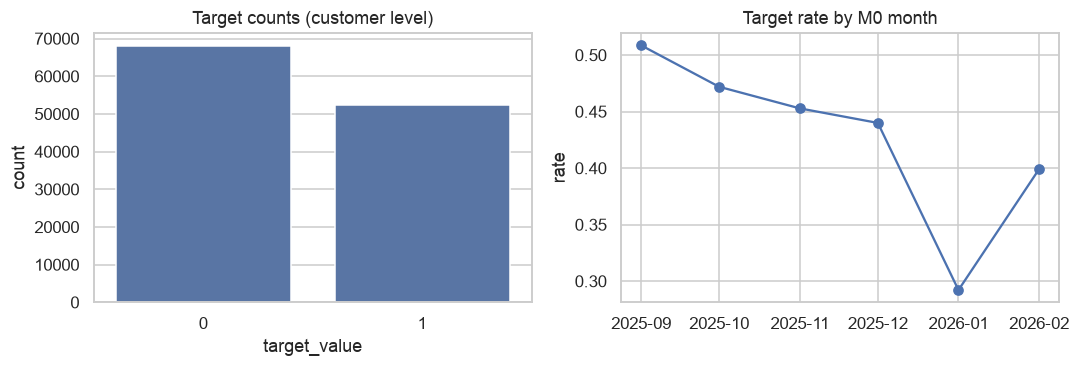

,target_rate,n_customers
month,,
2025-09-01,0.5086,35252
2025-10-01,0.4719,19489
2025-11-01,0.4528,14262
2025-12-01,0.4399,15127
2026-01-01,0.2921,21887
2026-02-01,0.3991,14407


In [7]:
vc = cust[TARGET].value_counts(dropna=False).sort_index()
rate = cust[TARGET].mean()
print(vc.to_string())
print(f"\nPositive rate (missed payments): {rate:.2%}   |   imbalance ratio ~ 1:{(1-rate)/rate:,.1f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.countplot(x=TARGET, data=cust, ax=ax[0])
ax[0].set_title("Target counts (customer level)")
tmp = cust.dropna(subset=[M0]).assign(month=lambda d: d[M0].dt.to_period("M").dt.to_timestamp())
m = tmp.groupby("month")[TARGET].agg(["mean", "count"])
ax[1].plot(m.index, m["mean"], marker="o")
ax[1].set_title("Target rate by M0 month"); ax[1].set_ylabel("rate")
plt.tight_layout(); plt.show()
display(m.rename(columns={"mean": "target_rate", "count": "n_customers"}))

In [8]:
# Validate the label definition: target = 1 if payment_count < due_count
if {"payment_count", "due_count"} <= set(cust.columns):
    derived = (cust["payment_count"] < cust["due_count"]).astype(int)
    mismatch = (derived != cust[TARGET])
    print(f"Label disagrees with (payment_count < due_count) for {mismatch.sum():,} rows ({mismatch.mean():.2%})")
    if mismatch.any():
        display(cust.loc[mismatch, ["due_count", "payment_count", TARGET]].head(10))
    display(pd.crosstab(cust["due_count"], cust["payment_count"], margins=True))

Label disagrees with (payment_count < due_count) for 19,401 rows (16.11%)


,due_count,payment_count,target_value
6,3,5,1
10,3,3,1
13,3,3,1
20,3,3,1
23,3,1,0
40,3,6,1
41,3,2,0
59,3,4,1
72,2,1,0
78,3,3,1


payment_count,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,58,60,61,62,63,64,65,66,67,69,70,71,72,73,74,75,77,78,83,84,85,86,91,94,95,107,109,113,121,161,All
due_count,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,109,113,177,96,41,21,12,8,3,2,7,1,3,0,1,4,1,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,604
2,225,180,192,209,154,120,67,44,44,30,20,16,13,16,8,5,6,6,3,7,4,2,2,1,2,1,2,1,5,1,0,1,1,0,3,1,0,0,0,0,1,0,0,0,1,0,2,0,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1401
3,21479,7636,10712,18889,29590,12004,8766,3502,1754,1079,689,446,337,241,192,150,121,107,90,70,61,40,48,42,27,38,25,15,31,14,29,13,6,16,12,10,10,6,8,6,3,8,4,4,3,4,13,4,3,4,2,2,2,1,4,1,2,1,2,1,1,6,3,1,1,1,2,2,1,1,3,1,1,3,0,1,1,1,1,1,1,1,1,1,1,2,1,118419
All,21813,7929,11081,19194,29785,12145,8845,3554,1801,1111,716,463,353,257,201,159,128,114,93,77,65,43,50,44,29,39,27,16,37,15,29,14,8,16,15,11,10,6,8,6,4,8,4,4,4,4,15,4,5,4,2,3,2,1,4,1,2,1,2,1,1,6,3,1,1,1,2,2,1,1,3,1,1,3,1,1,1,1,1,1,1,2,1,1,1,2,1,120424


## 5. Customer-level (account) variables vs target

Note: `payment_count` and `total_paid` describe the outcome period, so they are shown here for
understanding and label validation only. They must **not** be used as predictors.

In [9]:
def slog(x):
    """Signed log transform, handles zero/negative values."""
    return np.sign(x) * np.log1p(np.abs(x))

c = cust.copy()
if {"payment_count", "due_count"} <= set(c.columns):
    c["payment_ratio"] = c["payment_count"] / c["due_count"].replace(0, np.nan)
if {"total_paid", "m0_total_due_with_arrears"} <= set(c.columns):
    c["paid_to_due_ratio"] = c["total_paid"] / c["m0_total_due_with_arrears"].replace(0, np.nan)
if {"m0_arrearsamount", "m0_total_due_with_arrears"} <= set(c.columns):
    c["arrears_share_of_due"] = c["m0_arrearsamount"] / c["m0_total_due_with_arrears"].replace(0, np.nan)

num_cols = [x for x in CUST_NUM + ["payment_ratio", "paid_to_due_ratio", "arrears_share_of_due"] if x in c.columns]
display(c.groupby(TARGET)[num_cols].describe().T)

target_value                                 0            1
m0_arrearsamount          count    68,042.0000  52,382.0000
                          mean      1,088.9927   1,322.4849
                          std       1,895.2084   2,196.5491
                          min          50.0000      50.0000
                          25%         352.7000     413.4125
                          50%         667.7500     744.9650
                          75%       1,326.4900   1,496.4725
                          max     333,902.2188 180,875.3125
due_count                 count    68,042.0000  52,382.0000
                          mean          2.9701       2.9890
                          std           0.2094       0.1210
                          min           1.0000       1.0000
                          25%           3.0000       3.0000
                          50%           3.0000       3.0000
                          75%           3.0000       3.0000
                          max           3.0000       3.0000
payment_count             count    68,042.0000  52,382.0000
                          mean          4.8301       1.7753
                          std           3.7054       2.1253
                          min           0.0000       0.0000
                          25%           4.0000       0.0000
                          50%           4.0000       1.0000
                          75%           5.0000       3.0000
                          max         161.0000      60.0000
m0_total_due_with_arrears count    68,042.0000  52,382.0000
                          mean      4,157.1611   4,398.1138
                          std       6,378.7974   6,551.9761
                          min        -596.6200     -29.7100
                          25%       1,428.9200   1,335.3775
                          50%       2,627.2250   2,425.0050
                          75%       5,191.5502   5,060.1774
                          max   1,138,196.3750 205,783.0781
total_paid                count    68,042.0000  52,382.0000
                          mean      7,529.3921   1,003.4232
                          std      20,028.6875   2,386.5090
                          min     -13,311.2197  -9,070.0000
                          25%       1,673.1600       0.0000
                          50%       3,317.2700     100.0000
                          75%       7,247.4799   1,058.3375
                          max   1,346,658.0000 145,700.0000
payment_ratio             count    68,042.0000  52,382.0000
                          mean          1.6393       0.5931
                          std           1.3153       0.7091
                          min           0.0000       0.0000
                          25%           1.3333       0.0000
                          50%           1.3333       0.3333
                          75%           1.6667       1.0000
                          max          53.6667      20.0000
paid_to_due_ratio         count    68,042.0000  52,382.0000
                          mean          2.1479       0.2528
                          std           6.5294       0.5515
                          min         -34.8927      -1.4098
                          25%           1.0000       0.0000
                          50%           1.0000       0.0477
                          75%           1.3374       0.4964
                          max         813.6273      80.1607
arrears_share_of_due      count    68,042.0000  52,382.0000
                          mean          0.2682       0.3141
                          std           0.0869       0.1349
                          min          -0.3569     -14.6221
                          25%           0.2369       0.2531
                          50%           0.2658       0.3083
                          75%           0.3002       0.3489
                          max           1.3710       1.0000

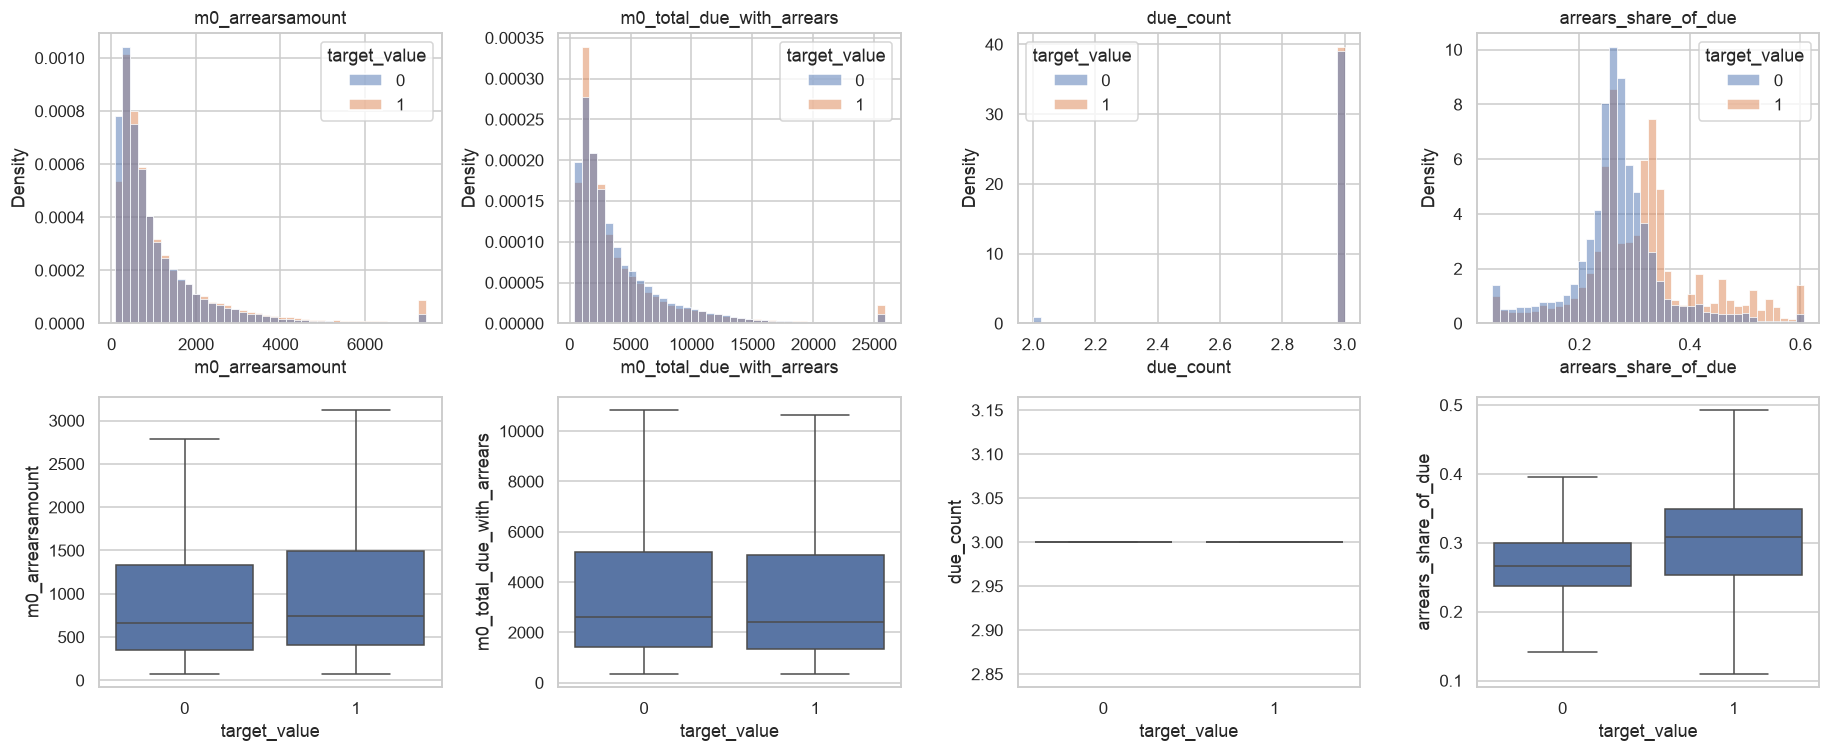

In [10]:
plot_cols = [x for x in ["m0_arrearsamount", "m0_total_due_with_arrears", "due_count", "arrears_share_of_due"] if x in c.columns]
fig, axes = plt.subplots(2, len(plot_cols), figsize=(4.2 * len(plot_cols), 7))
axes = np.atleast_2d(axes)
for i, col in enumerate(plot_cols):
    s = c[col].dropna()
    lo, hi = s.quantile([0.01, 0.99])
    d = c[[col, TARGET]].dropna()
    d[col] = d[col].clip(lo, hi)
    sns.histplot(data=d, x=col, hue=TARGET, stat="density", common_norm=False, bins=40, ax=axes[0, i])
    axes[0, i].set_title(col)
    sns.boxplot(data=d, x=TARGET, y=col, showfliers=False, ax=axes[1, i])
plt.tight_layout(); plt.show()

In [11]:
# Univariate separation of account-level (non-leaky) variables
rows = []
for col in [x for x in num_cols if x not in LEAKY and x not in ["payment_ratio", "paid_to_due_ratio"]]:
    a = c.loc[c[TARGET] == 1, col].dropna(); b = c.loc[c[TARGET] == 0, col].dropna()
    if len(a) > 20 and len(b) > 20:
        u, p = stats.mannwhitneyu(a, b)
        rows.append({"feature": col, "median_target1": a.median(), "median_target0": b.median(),
                     "AUC": u / (len(a) * len(b)), "p_value": p})
display(pd.DataFrame(rows).set_index("feature"))

,median_target1,median_target0,AUC,p_value
feature,,,,
m0_arrearsamount,744.9650,667.7500,0.5378,0.0000
due_count,3.0000,3.0000,0.5067,0.0000
m0_total_due_with_arrears,"2,425.0049","2,627.2251",0.4917,0.0000
arrears_share_of_due,0.3083,0.2658,0.6354,0.0000


,count,n_pos,rate,ci_lo,ci_hi,lift
collectionsmethodname,,,,,,
"Early Debit Order, linked to clients paydate",79080,40840,0.5164,0.5130,0.5199,1.1873
Debit Order,39521,11060,0.2799,0.2754,0.2843,0.6434
"Credit push, client pays via EFT",1823,482,0.2644,0.2447,0.2851,0.6078


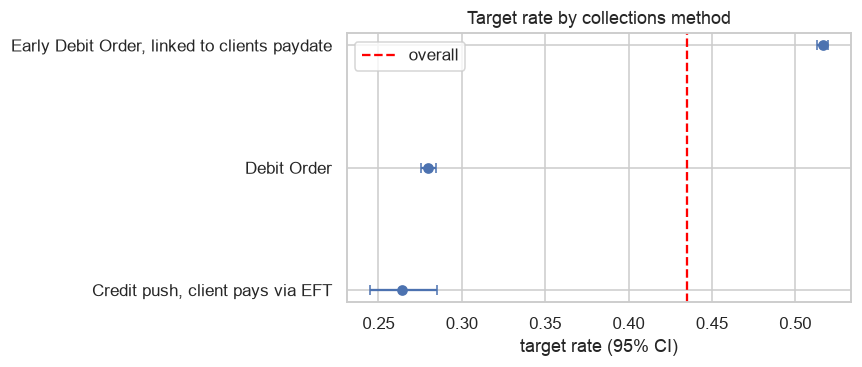

In [12]:
def rate_table(d, col, target=TARGET, min_n=30, top=None):
    """Target rate by category with Wilson 95% CI and lift vs overall rate."""
    g = d.groupby(col, observed=True)[target].agg(["count", "sum"]).rename(columns={"sum": "n_pos"})
    g["rate"] = g["n_pos"] / g["count"]
    lo, hi = proportion_confint(g["n_pos"], g["count"], method="wilson")
    g["ci_lo"], g["ci_hi"] = lo, hi
    g["lift"] = g["rate"] / d[target].mean()
    g = g[g["count"] >= min_n].sort_values("count", ascending=False)
    return g.head(top) if top else g

if METHOD in cust.columns:
    rt = rate_table(cust, METHOD)
    display(rt)
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(rt) + 2))
    rt_s = rt.sort_values("rate")
    ax.errorbar(rt_s["rate"], range(len(rt_s)),
                xerr=[rt_s["rate"] - rt_s["ci_lo"], rt_s["ci_hi"] - rt_s["rate"]], fmt="o", capsize=3)
    ax.set_yticks(range(len(rt_s))); ax.set_yticklabels(rt_s.index)
    ax.axvline(cust[TARGET].mean(), color="red", ls="--", label="overall")
    ax.set_xlabel("target rate (95% CI)"); ax.set_title("Target rate by collections method"); ax.legend()
    plt.tight_layout(); plt.show()

## 6. Transaction-level overview

Transactions: 52,025,014 across 120,424 customers
Date range  : 2025-05-01 -> 2026-02-27


,count,mean,std,min,5%,25%,50%,75%,95%,max
transactions per customer,"120,424.0000",432.0153,381.2404,2.0000,52.0000,160.0000,327.0000,588.0000,"1,165.0000","8,232.0000"



Inflows (amount>0): 22.6% of rows | outflows (amount<0): 77.4% | zero: 0.0%
Balance negative at transaction time: 7.5%


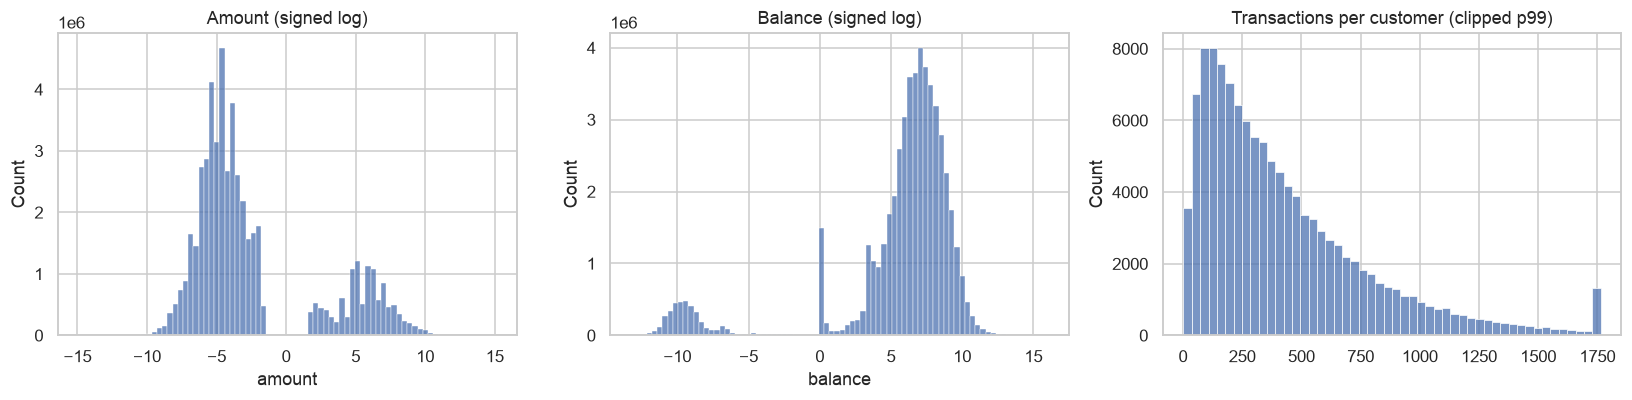

In [13]:
print(f"Transactions: {len(txn):,} across {txn[ID].nunique():,} customers")
print(f"Date range  : {txn[TXN_DATE].min().date()} -> {txn[TXN_DATE].max().date()}")

tpc = txn.groupby(KEY, dropna=False).size()
display(tpc.describe(percentiles=[.05, .25, .5, .75, .95]).to_frame("transactions per customer").T)

print(f"\nInflows (amount>0): {(txn[AMT] > 0).mean():.1%} of rows | outflows (amount<0): {(txn[AMT] < 0).mean():.1%} | zero: {(txn[AMT] == 0).mean():.1%}")
print(f"Balance negative at transaction time: {(txn[BAL] < 0).mean():.1%}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
sns.histplot(slog(txn[AMT].dropna()), bins=80, ax=ax[0]); ax[0].set_title("Amount (signed log)")
sns.histplot(slog(txn[BAL].dropna()), bins=80, ax=ax[1]); ax[1].set_title("Balance (signed log)")
sns.histplot(tpc.clip(upper=tpc.quantile(.99)), bins=50, ax=ax[2]); ax[2].set_title("Transactions per customer (clipped p99)")
plt.tight_layout(); plt.show()


=== trantypedesc: 249 levels (top 20 shown) ===


,n,net_amount,mean_amount,pct_inflow,share_%
trantypedesc,,,,,
Card Purchase,14936801,"-3,782,662,144.0000",-253.2445,0.0000,28.7108
Transfer,4645835,"-4,212,408,064.0000",-906.7064,0.0859,8.9300
Transfer Received,3929926,"4,681,745,408.0000","1,191.3063",1.0000,7.5539
Prepaid Purchase,3373328,"-162,207,408.0000",-48.0853,0.0000,6.4841
Payment Received,3249129,"9,109,794,816.0000","2,803.7651",1.0000,6.2453
Immediate Payment,2870817,"-2,655,650,560.0000",-925.0505,0.0000,5.5181
Voucher Purchase,1586090,"-173,098,128.0000",-109.1351,0.0000,3.0487
Cash Withdrawal,1441093,"-1,176,032,768.0000",-816.0700,0.0000,2.7700
Immediate Capitec Pay Payment,1335231,"-431,835,296.0000",-323.4162,0.0000,2.5665


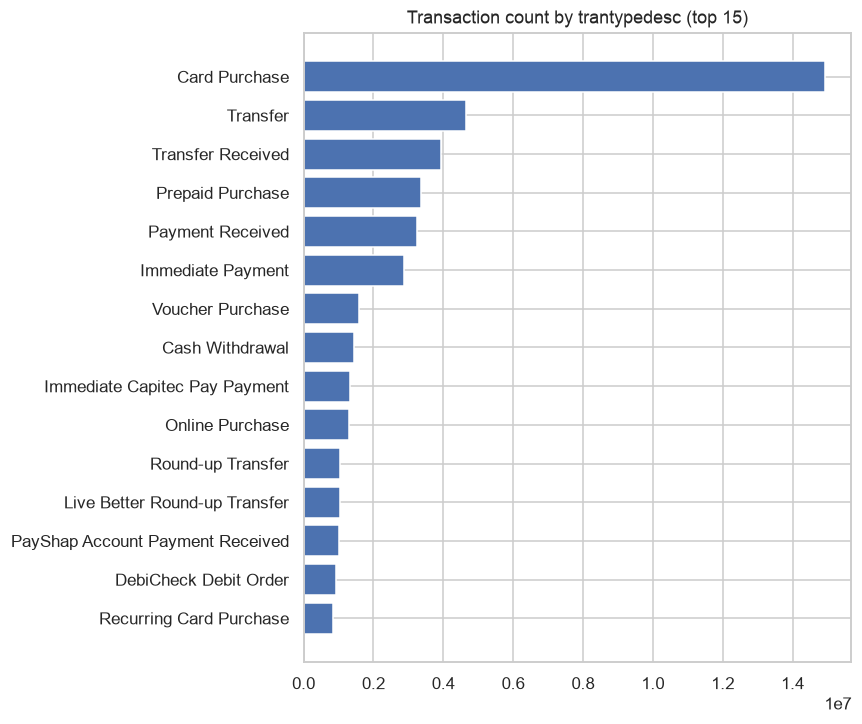


=== spendgroup: 38 levels (top 20 shown) ===


,n,net_amount,mean_amount,pct_inflow,share_%
spendgroup,,,,,
InternalTransfer,9724718,"426,290,848.0000",43.8358,0.4480,18.6924
CardAuthorisationTransaction,8751771,"-2,266,122,496.0000",-258.9330,0.0001,16.8222
CardTransaction,8554615,"-2,216,868,608.0000",-259.1430,0.0019,16.4433
MoneyIn,4434621,"10,210,201,600.0000","2,302.3843",0.9989,8.5240
Prepaid,3479421,"-158,104,736.0000",-45.4400,0.0270,6.6880
PaymentInternal,3112068,"-2,869,017,088.0000",-921.9005,0.0008,5.9819
Fee,1776238,"-24,395,192.0000",-13.7342,0.0179,3.4142
Vouchers,1589566,"-172,702,976.0000",-108.6479,0.0022,3.0554
CapitecPay,1408946,"-475,908,096.0000",-337.7760,0.0000,2.7082


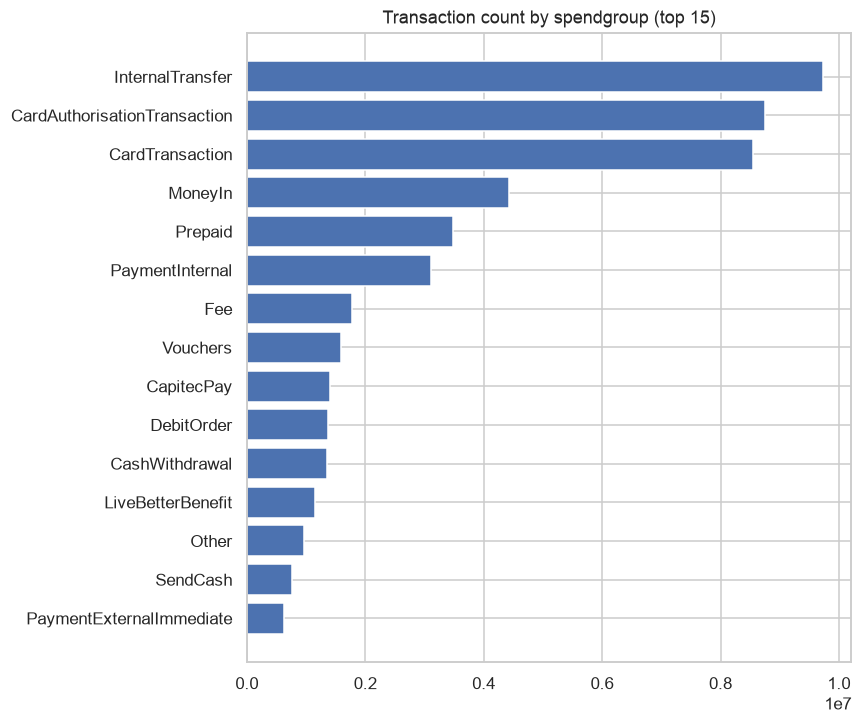


=== categoryname: 103 levels (top 20 shown) ===


,n,net_amount,mean_amount,pct_inflow,share_%
categoryname,,,,,
Transfer,9756191,"421,866,080.0000",43.2409,0.4482,18.7529
Groceries,7065448,"-1,568,931,712.0000",-222.0569,0.0001,13.5809
Cellphone,3755432,"-221,902,064.0000",-59.0883,0.0124,7.2185
Other Income,3684602,"5,519,918,080.0000","1,498.1042",0.9997,7.0824
Digital Payments,3437103,"-3,578,882,048.0000","-1,041.2496",0.0026,6.6066
Betting/Lottery,3366374,"-451,305,216.0000",-134.0627,0.0632,6.4707
Cash Withdrawal,2207426,"-1,506,041,344.0000",-682.2613,0.0231,4.2430
Fees,1776238,"-24,395,192.0000",-13.7342,0.0179,3.4142
Fuel,1652913,"-452,304,000.0000",-273.6405,0.0004,3.1772


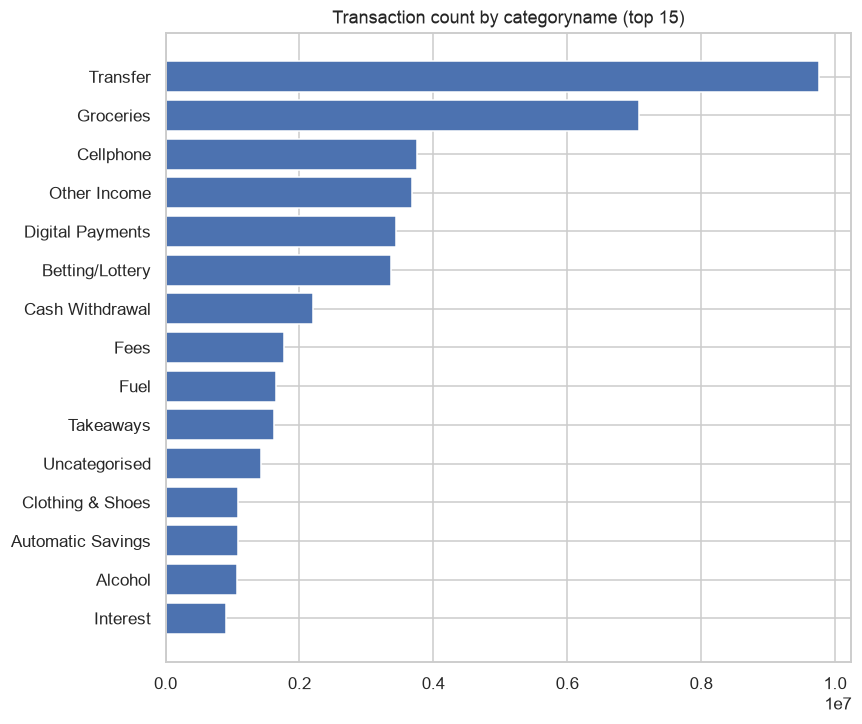

In [14]:
# Categorical structure of transactions
for col in [TXN_TYPE, SPEND, CAT]:
    if col not in txn.columns:
        continue
    g = (txn.groupby(col, observed=True)
            .agg(n=(AMT, "size"), net_amount=(AMT, "sum"), mean_amount=(AMT, "mean"),
                 pct_inflow=(AMT, lambda s: (s > 0).mean()))
            .sort_values("n", ascending=False))
    g["share_%"] = g["n"] / g["n"].sum() * 100
    print(f"\n=== {col}: {len(g)} levels (top 20 shown) ===")
    display(g.head(20))
    top = g.head(15).sort_values("n")
    fig, ax = plt.subplots(figsize=(8, 0.35 * len(top) + 1.5))
    ax.barh(top.index.astype(str), top["n"]); ax.set_title(f"Transaction count by {col} (top 15)")
    plt.tight_layout(); plt.show()

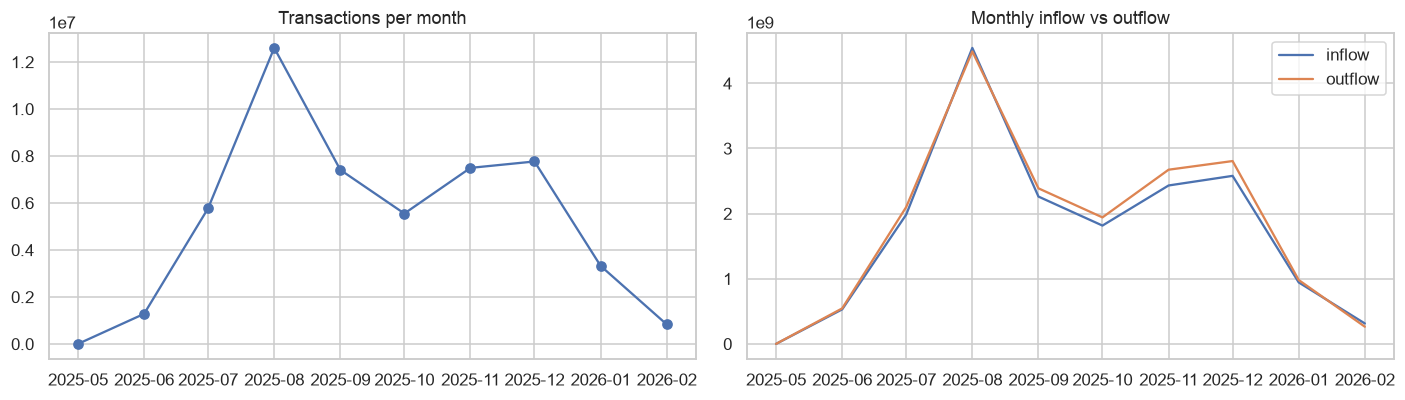

In [15]:
# Monthly volume and net flow
mt = txn.assign(month=txn[TXN_DATE].dt.to_period("M").dt.to_timestamp())
mm = mt.groupby("month").agg(n=(AMT, "size"),
                             inflow=(AMT, lambda s: s[s > 0].sum()),
                             outflow=(AMT, lambda s: -s[s < 0].sum()))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].plot(mm.index, mm["n"], marker="o"); ax[0].set_title("Transactions per month")
ax[1].plot(mm.index, mm["inflow"], label="inflow"); ax[1].plot(mm.index, mm["outflow"], label="outflow")
ax[1].legend(); ax[1].set_title("Monthly inflow vs outflow")
plt.tight_layout(); plt.show()

## 7. Time windows and leakage checks

Features must use only information available **at or before M0**, because the target is measured in the
3 months after M0. We check how much transaction history sits before vs after M0.

Transactions dated AFTER M0 (must be excluded from features): 0 (0.00%)
Transactions within the 90-day window before M0: 86.36%


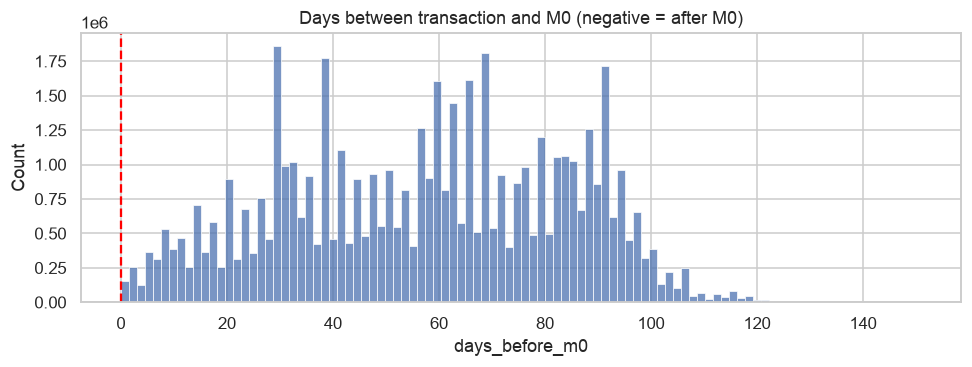

,count,mean,std,min,5%,25%,50%,75%,95%,max
max days of history before M0,"120,424.0000",98.3122,7.2952,28.0000,91.0000,93.0000,97.0000,100.0000,115.0000,151.0000


Customers in cust table with NO pre-M0 transactions: 0


,count,mean,std,min,25%,50%,75%,max
payment_date - M0 (days),"120,424.0000",-6.6604,6.9242,-30.0000,-8.0000,-5.0000,-1.0000,0.0000


In [16]:
txn["days_before_m0"] = (txn[M0] - txn[TXN_DATE]).dt.days
after = (txn["days_before_m0"] < 0)
print(f"Transactions dated AFTER M0 (must be excluded from features): {after.sum():,} ({after.mean():.2%})")
print(f"Transactions within the {WINDOW_DAYS}-day window before M0: "
      f"{((txn['days_before_m0'] >= 0) & (txn['days_before_m0'] < WINDOW_DAYS)).mean():.2%}")

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.histplot(txn["days_before_m0"].clip(-120, 400), bins=100, ax=ax)
ax.axvline(0, color="red", ls="--"); ax.set_title("Days between transaction and M0 (negative = after M0)")
plt.tight_layout(); plt.show()

# History coverage per customer (pre-M0)
pre = txn[txn["days_before_m0"] >= 0]
cov = pre.groupby(KEY, dropna=False)["days_before_m0"].max()
display(cov.describe(percentiles=[.05, .25, .5, .75, .95]).to_frame("max days of history before M0").T)
print(f"Customers in cust table with NO pre-M0 transactions: {len(cust) - len(cov):,}")

# Payment dates relative to M0
pay2 = pay.dropna(subset=[PAY_DATE, M0]).copy()
pay2["days_after_m0"] = (pay2[PAY_DATE] - pay2[M0]).dt.days
display(pay2["days_after_m0"].describe().to_frame("payment_date - M0 (days)").T)

## 8. Behavioural feature engineering (pre-M0 window)

In [17]:
w = txn[(txn["days_before_m0"] >= 0) & (txn["days_before_m0"] < WINDOW_DAYS)].copy()
w["inflow"] = w[AMT].clip(lower=0)
w["outflow"] = (-w[AMT]).clip(lower=0)
w["is_in"] = (w[AMT] > 0).astype(int)
w["is_out"] = (w[AMT] < 0).astype(int)
w["neg_bal"] = (w[BAL] < 0).astype(int)
w = w.sort_values(TXN_DATE)

feat = w.groupby(KEY, dropna=False).agg(
    n_txn=(AMT, "size"),
    active_days=(TXN_DATE, "nunique"),
    inflow_sum=("inflow", "sum"),
    outflow_sum=("outflow", "sum"),
    n_inflow=("is_in", "sum"),
    n_outflow=("is_out", "sum"),
    max_inflow=("inflow", "max"),
    max_outflow=("outflow", "max"),
    bal_mean=(BAL, "mean"),
    bal_min=(BAL, "min"),
    bal_max=(BAL, "max"),
    bal_std=(BAL, "std"),
    bal_last=(BAL, "last"),
    pct_neg_bal=("neg_bal", "mean"),
)
feat["net_flow"] = feat["inflow_sum"] - feat["outflow_sum"]
feat["outflow_to_inflow"] = feat["outflow_sum"] / feat["inflow_sum"].replace(0, np.nan)
feat["avg_outflow_size"] = feat["outflow_sum"] / feat["n_outflow"].replace(0, np.nan)
feat["avg_inflow_size"] = feat["inflow_sum"] / feat["n_inflow"].replace(0, np.nan)

# Income-regularity proxy: coefficient of variation of inflow amounts
inc = w[w[AMT] > 0].groupby(KEY, dropna=False)[AMT].agg(["mean", "std"])
feat["inflow_cv"] = (inc["std"] / inc["mean"]).reindex(feat.index)

# Spend-group shares of outflow
if SPEND in w.columns:
    sp = (w[w[AMT] < 0].groupby(KEY + [SPEND], observed=True, dropna=False)["outflow"]
            .sum().unstack(fill_value=0))
    top_groups = sp.sum().sort_values(ascending=False).head(12).index
    sp = sp[top_groups]
    sp_share = sp.div(sp.sum(axis=1).replace(0, np.nan), axis=0).add_prefix("share_")
    sp_share.columns = [str(c).replace(" ", "_").lower() for c in sp_share.columns]
    feat = feat.join(sp_share)

# Account-level variables known at M0 (non-leaky)
acct_cols = [x for x in ["m0_arrearsamount", "m0_total_due_with_arrears", "due_count"] if x in cust.columns]
features = cust.set_index(KEY)[[TARGET] + acct_cols + ([METHOD] if METHOD in cust.columns else [])].join(feat)

for col in ["n_txn", "active_days", "inflow_sum", "outflow_sum", "n_inflow", "n_outflow", "net_flow"]:
    features[col] = features[col].fillna(0)
features["no_txn_in_window"] = (features["n_txn"] == 0).astype(int)

print(f"Feature table: {features.shape}  |  customers with no transactions in window: {features['no_txn_in_window'].mean():.2%}")
display(features.head())
display(features.isna().mean().sort_values(ascending=False).head(15).to_frame("missing share"))

Feature table: (120424, 37)  |  customers with no transactions in window: 0.00%


,,target_value,m0_arrearsamount,m0_total_due_with_arrears,due_count,collectionsmethodname,n_txn,active_days,inflow_sum,outflow_sum,n_inflow,n_outflow,max_inflow,max_outflow,bal_mean,bal_min,bal_max,bal_std,bal_last,pct_neg_bal,net_flow,outflow_to_inflow,avg_outflow_size,avg_inflow_size,inflow_cv,share_internaltransfer,share_paymentinternal,share_cardauthorisationtransaction,share_cardtransaction,share_debitorder,share_cashwithdrawal,share_paymentexternalimmediate,share_paymentexternal,share_capitecpay,share_sendcash,share_other,share_vouchers,no_txn_in_window
cifwithcheckdigit,m0_monthenddate,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
100000487,2025-09-30,1,185.9700,726.4100,3,"Early Debit Order, linked to clients paydate",27,24,"4,924.4399","3,322.2400",6,21,"3,028.0200","1,000.0000",-481.6022,"-3,580.8799","3,038.2900","2,004.1375",0.0000,0.2963,"1,602.2000",0.6746,158.2019,820.7400,1.3294,0.0000,0.0000,0.0000,0.0000,0.5985,0.3446,0.0000,0.0000,0.0000,0.0000,0.0570,0.0000,0
100007589,2025-12-31,0,"3,955.5100","8,458.4902",3,"Early Debit Order, linked to clients paydate",438,307,"82,621.7734","77,767.7812",99,339,"27,446.3594","16,095.3701",-778.6193,"-23,511.9609","27,953.5801","7,104.4399","-22,421.4102",0.0959,"4,853.9922",0.9413,229.4035,834.5634,3.8801,0.1295,0.2293,0.1331,0.1680,0.2601,0.0308,0.0065,0.0266,0.0073,0.0000,0.0089,0.0000,0
100010555,2025-10-31,0,521.0900,"1,898.3101",3,"Early Debit Order, linked to clients paydate",601,331,"168,665.8438","275,268.3750",107,494,"42,343.2305","18,000.0000","2,589.4543","-6,680.5498","42,350.4492","5,209.7449",110.2100,0.0316,"-106,602.5312",1.6320,557.2234,"1,576.3163",3.1446,0.2484,0.0842,0.0979,0.1663,0.0038,0.0914,0.0000,0.2627,0.0000,0.0432,0.0022,0.0000,0
100012752,2025-09-30,0,"3,575.1201","6,603.9800",3,"Early Debit Order, linked to clients paydate",88,44,"39,721.2305","8,607.0801",19,69,"7,401.4502",637.2700,-854.2328,"-22,351.3008","1,572.5800","5,781.0674",0.0000,0.0909,"31,114.1504",0.2167,124.7403,"2,090.5911",1.1583,0.0014,0.0000,0.6097,0.2656,0.0000,0.0320,0.0000,0.0000,0.0000,0.0000,0.0912,0.0000,0
100013708,2026-01-31,0,781.5200,"6,199.7100",3,Debit Order,411,246,"190,200.9688","169,472.8125",60,351,"29,822.0391","12,500.0000","1,464.4519","-33,778.6016","29,998.1309","6,787.8627","4,500.8701",0.0292,"20,728.1562",0.8910,482.8285,"3,170.0161",1.6410,0.4263,0.0394,0.1081,0.0940,0.1099,0.0783,0.1341,0.0000,0.0000,0.0000,0.0095,0.0003,0


,missing share
inflow_cv,0.0005
share_debitorder,0.0001
share_vouchers,0.0001
share_other,0.0001
share_sendcash,0.0001
share_capitecpay,0.0001
share_paymentexternal,0.0001
share_paymentexternalimmediate,0.0001
share_cashwithdrawal,0.0001
share_cardtransaction,0.0001


## 9. Features vs target

In [18]:
feat_cols = [c for c in features.select_dtypes("number").columns if c not in [TARGET, "no_txn_in_window"]]
rows = []
for col in feat_cols:
    a = features.loc[features[TARGET] == 1, col].dropna()
    b = features.loc[features[TARGET] == 0, col].dropna()
    if len(a) > 20 and len(b) > 20 and features[col].nunique() > 1:
        u, p = stats.mannwhitneyu(a, b)
        auc = u / (len(a) * len(b))
        rows.append({"feature": col, "median_target1": a.median(), "median_target0": b.median(),
                     "AUC": auc, "separation": abs(auc - 0.5) * 2, "p_value": p})
sep = pd.DataFrame(rows).set_index("feature").sort_values("separation", ascending=False)
display(sep)
print("AUC > 0.5: higher values associated with target=1 (missed payments); < 0.5: lower values.")

,median_target1,median_target0,AUC,separation,p_value
feature,,,,,
bal_last,33.6500,247.9100,0.3441,0.3118,0.0000
outflow_sum,"55,340.4453","89,150.9141",0.3915,0.2169,0.0000
bal_max,"9,794.9199","13,945.4453",0.4056,0.1889,0.0000
avg_outflow_size,292.8453,366.9127,0.4066,0.1867,0.0000
outflow_to_inflow,1.0092,1.0967,0.4103,0.1793,0.0000
max_inflow,"8,923.1895","12,446.2100",0.4122,0.1756,0.0000
net_flow,-373.8545,"-6,114.6074",0.5876,0.1751,0.0000
bal_mean,478.5660,"1,035.9581",0.4136,0.1727,0.0000
share_other,0.0105,0.0070,0.5818,0.1637,0.0000


AUC > 0.5: higher values associated with target=1 (missed payments); < 0.5: lower values.


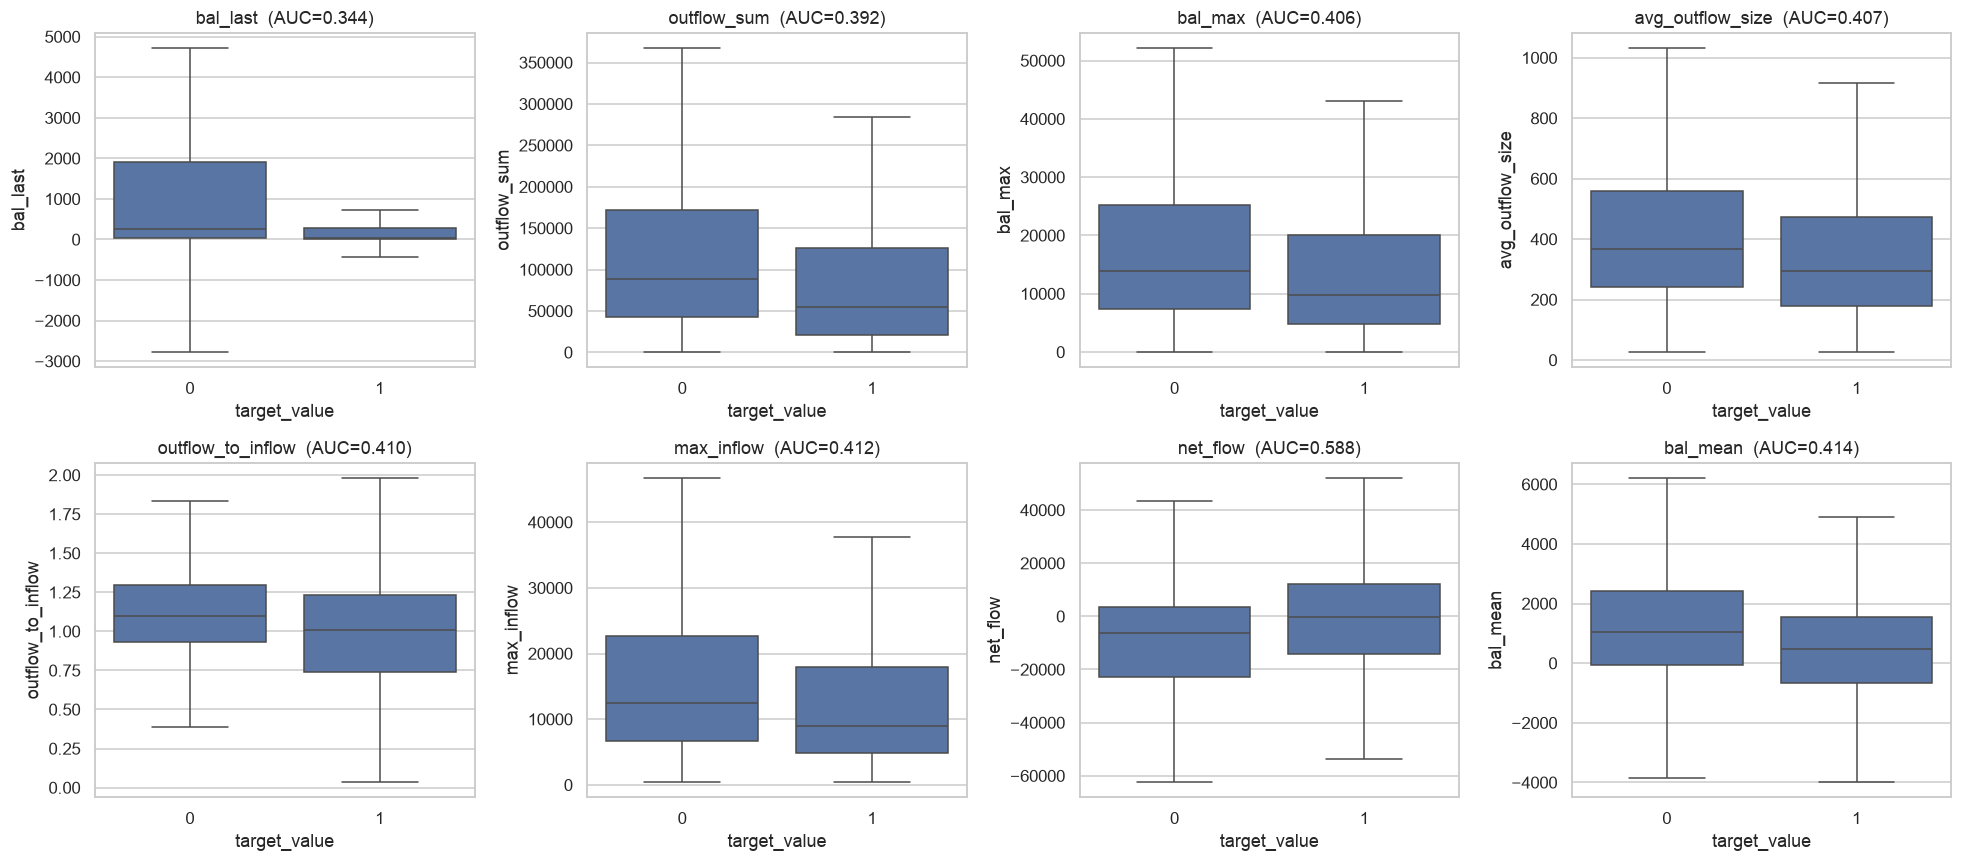

In [19]:
top_feats = sep.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), top_feats):
    d = features[[col, TARGET]].dropna()
    lo, hi = d[col].quantile([0.01, 0.99])
    d[col] = d[col].clip(lo, hi)
    sns.boxplot(data=d, x=TARGET, y=col, showfliers=False, ax=ax)
    ax.set_title(f"{col}  (AUC={sep.loc[col, 'AUC']:.3f})")
plt.tight_layout(); plt.show()

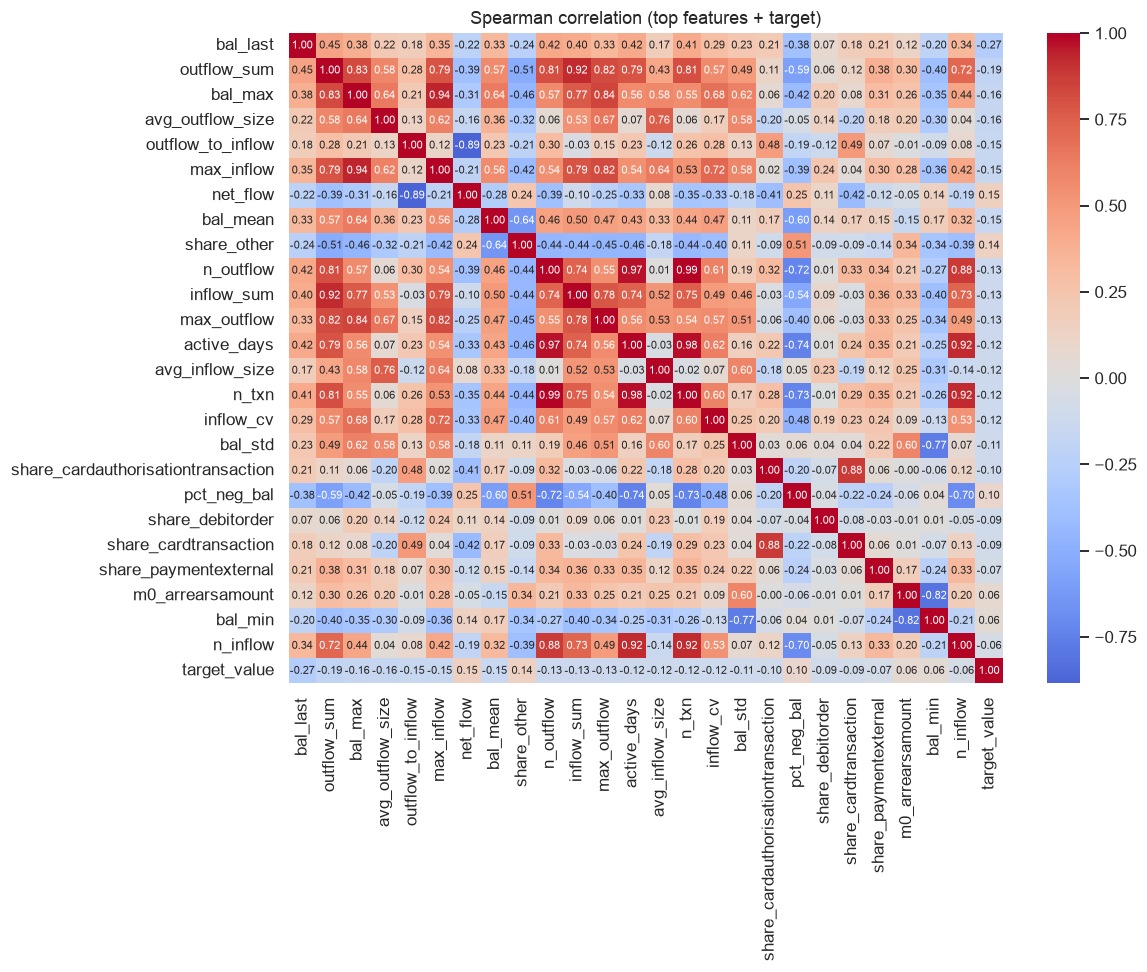

,f1,f2,rho
248,n_outflow,n_txn,0.9943
326,active_days,n_txn,0.9756
246,n_outflow,active_days,0.9653
57,bal_max,max_inflow,0.9359
388,n_txn,n_inflow,0.9225
36,outflow_sum,inflow_sum,0.9209
336,active_days,n_inflow,0.9208
110,outflow_to_inflow,net_flow,-0.8854
258,n_outflow,n_inflow,0.8788
462,share_cardauthorisationtransaction,share_cardtransaction,0.8778


In [23]:
# Spearman correlation among the most informative features + target
cols = sep.head(25).index.tolist() + [TARGET]
corr = features[cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)
ax.set_title("Spearman correlation (top features + target)")
plt.tight_layout(); plt.show()

# Highly collinear pairs (relevant for SOM feature selection)
pairs = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
             .rename("rho").reset_index().rename(columns={"level_0": "f1", "level_1": "f2"}))
display(pairs[pairs["rho"].abs() > 0.8].sort_values("rho", key=abs, ascending=False))

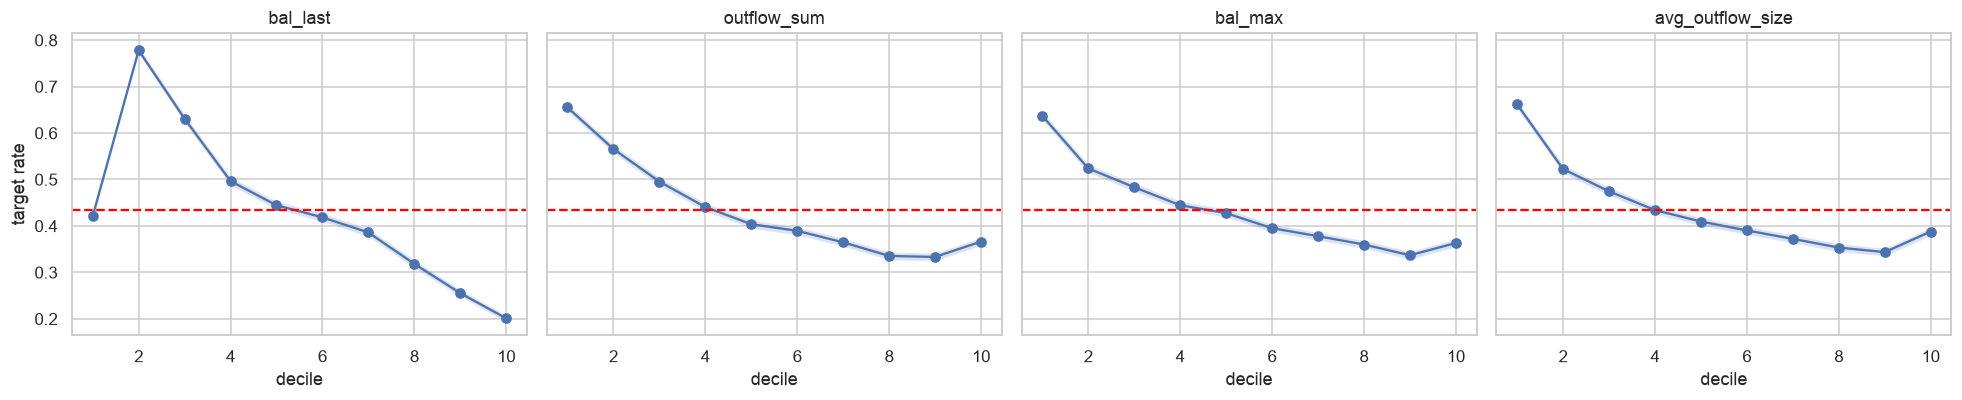

In [24]:
# Target rate by feature decile (shows shape of the relationship, incl. non-monotonic effects)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)
overall = features[TARGET].mean()
for ax, col in zip(axes, sep.head(4).index):
    d = features[[col, TARGET]].dropna()
    d["decile"] = pd.qcut(d[col].rank(method="first"), 10, labels=False) + 1
    g = d.groupby("decile")[TARGET].agg(["mean", "count", "sum"])
    lo, hi = proportion_confint(g["sum"], g["count"], method="wilson")
    ax.plot(g.index, g["mean"], marker="o"); ax.fill_between(g.index, lo, hi, alpha=0.2)
    ax.axhline(overall, color="red", ls="--"); ax.set_title(col); ax.set_xlabel("decile")
axes[0].set_ylabel("target rate")
plt.tight_layout(); plt.show()

## 10. Category-level risk

In [25]:
# For each category: among customers who transacted in it during the window, what is the target rate?
tgt = cust[KEY + [TARGET]]
for col in [SPEND, CAT]:
    if col not in w.columns:
        continue
    has = w[KEY + [col]].drop_duplicates().merge(tgt, on=KEY, how="left")
    rt = rate_table(has, col, min_n=50)
    rt["lift"] = rt["rate"] / cust[TARGET].mean()
    print(f"\n=== {col}: customers who transacted in the category (target rate vs overall {cust[TARGET].mean():.2%}) ===")
    display(rt.sort_values("lift", ascending=False).head(15))
    display(rt.sort_values("lift").head(10))


=== spendgroup: customers who transacted in the category (target rate vs overall 43.50%) ===


,count,n_pos,rate,ci_lo,ci_hi,lift
spendgroup,,,,,,
INSURANCE_PAYOUT,174,125,0.7184,0.6474,0.7799,1.6516
UnpaidOrBouncedDebitOrder,82627,38305,0.4636,0.4602,0.4670,1.0658
InternationalPayments,118,54,0.4576,0.3705,0.5474,1.0521
PrepaidCapitecConnectAdvanceRepay,3390,1551,0.4575,0.4408,0.4743,1.0518
AccountClosure,128,58,0.4531,0.3695,0.5395,1.0417
UnpaidOrBouncedStandingOrder,9055,4088,0.4515,0.4412,0.4617,1.0379
Vouchers,30792,13851,0.4498,0.4443,0.4554,1.0341
NonFinancial,94450,42422,0.4491,0.4460,0.4523,1.0326
INSURANCE_PAYMENTS,5439,2379,0.4374,0.4243,0.4506,1.0056


,count,n_pos,rate,ci_lo,ci_hi,lift
spendgroup,,,,,,
StandingOrderInternalTransfer,3632,1093,0.3009,0.2862,0.3161,0.6918
StandingOrderPaymentInternal,1484,469,0.3160,0.2929,0.3401,0.7266
StandingOrderPaymentExternal,3461,1105,0.3193,0.3039,0.3350,0.7340
LicenceDiscRenewal,1685,594,0.3525,0.3301,0.3756,0.8104
Interest,31175,11323,0.3632,0.3579,0.3686,0.8350
CROSS_BORDER_MONEY_PAYMENT,84,31,0.3690,0.2737,0.4758,0.8484
CAPITEC_DEVICE_SALES,98,38,0.3878,0.2973,0.4867,0.8914
PaymentExternal,52192,20421,0.3913,0.3871,0.3955,0.8995
MerchantTransaction,448,176,0.3929,0.3487,0.4388,0.9032



=== categoryname: customers who transacted in the category (target rate vs overall 43.50%) ===


,count,n_pos,rate,ci_lo,ci_hi,lift
categoryname,,,,,,
Insurance Payout,191,133,0.6963,0.6278,0.7571,1.6008
Savings,14115,7780,0.5512,0.5430,0.5594,1.2672
UIF Received,5640,2924,0.5184,0.5054,0.5315,1.1919
Loans,9335,4610,0.4938,0.4837,0.5040,1.1353
Loan Payments,30144,13911,0.4615,0.4559,0.4671,1.0609
Credit Card Payments,77430,35206,0.4547,0.4512,0.4582,1.0453
Other Savings & Investments,951,427,0.4490,0.4177,0.4808,1.0322
Employee Refund,421,188,0.4466,0.3998,0.4943,1.0266
Child Support,1685,743,0.4409,0.4174,0.4648,1.0137


,count,n_pos,rate,ci_lo,ci_hi,lift
categoryname,,,,,,
Bonus,912,280,0.3070,0.2779,0.3377,0.7058
Municipal Bill,2815,885,0.3144,0.2975,0.3318,0.7228
Medical Aid,2325,735,0.3161,0.2975,0.3353,0.7268
Garden,2720,863,0.3173,0.3001,0.3350,0.7294
Other Household,3311,1056,0.3189,0.3033,0.3350,0.7332
Books/Stationery,398,127,0.3191,0.2752,0.3664,0.7336
Gifts,5753,1870,0.3250,0.3131,0.3373,0.7473
Gadgets,483,157,0.3251,0.2848,0.3681,0.7473
Pets,5188,1687,0.3252,0.3126,0.3380,0.7476


## 11. Save the customer-level feature table

In [26]:
out = features.reset_index()
out.to_parquet(OUTPUT_PATH, index=False)
print(f"Saved {out.shape[0]:,} rows x {out.shape[1]} columns to {OUTPUT_PATH}")
print("\nSuggested SOM inputs: behavioural columns only (exclude target, payment_count, total_paid).")
print("Remember to apply signed-log / robust scaling and impute missing values before training.")

Saved 120,424 rows x 39 columns to customer_features.parquet

Suggested SOM inputs: behavioural columns only (exclude target, payment_count, total_paid).
Remember to apply signed-log / robust scaling and impute missing values before training.


### Next steps
* Review the section 3 diagnostic: if transactions are duplicated per `payment_date`, set `DEDUPE_TXNS = True` and re-run.
* Pick 10 to 20 weakly correlated behavioural features from `features`, apply signed-log + standard/robust scaling, then train the SOM (e.g. MiniSom) **without** the target.
* Overlay `target_value` rate (with confidence intervals) per SOM node to find high-risk neighbourhoods.
* Validate with a supervised model (gradient boosting + SHAP) using a time-based train/test split on `m0_monthenddate`.